In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ACTIVITIES = {
    0: 'WALKING',
    1: 'WALKING_UPSTAIRS',
    2: 'WALKING_DOWNSTAIRS',
    3: 'SITTING',
    4: 'STANDING',
    5: 'LAYING',
}

def _read_csv(filename):
    return pd.read_csv(filename, delim_whitespace=True, header=None)

SIGNALS = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

def load_signals(subset):
    signals_data = []
    for signal in SIGNALS:
        filename = f'UCI_HAR_Dataset/{subset}/Inertial Signals/{signal}_{subset}.txt'
        signals_data.append(
            _read_csv(filename).to_numpy()
        ) 
    return np.transpose(signals_data, (1, 2, 0))

def load_y(subset):
    filename = f'UCI_HAR_Dataset/{subset}/y_{subset}.txt'
    y = _read_csv(filename)[0]
    return pd.get_dummies(y).to_numpy()

def load_data():
    X_train, X_test = load_signals('train'), load_signals('test')
    y_train, y_test = load_y('train'), load_y('test')
    return X_train, X_test, y_train, y_test

In [3]:
np.random.seed(42)
# Load dataset
X_train, X_test, Y_train, Y_test = load_data()

# Convert numpy arrays to torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

# Check the shape of your data
timesteps = len(X_train[0])
input_dim = len(X_train[0][0])
n_classes = Y_train.shape[1]

print(timesteps)
print(input_dim)
print(len(X_train))



C:\Users\Gopal\AppData\Local\Temp\ipykernel_15412\946597317.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(filename, delim_whitespace=True, header=None)
C:\Users\Gopal\AppData\Local\Temp\ipykernel_15412\946597317.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(filename, delim_whitespace=True, header=None)
C:\Users\Gopal\AppData\Local\Temp\ipykernel_15412\946597317.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(filename, delim_whitespace=True, header=None)
C:\Users\Gopal\AppData\Local\Temp\ipykernel_15412\946597317.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a futur

128
9
7352


C:\Users\Gopal\AppData\Local\Temp\ipykernel_15412\946597317.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(filename, delim_whitespace=True, header=None)
C:\Users\Gopal\AppData\Local\Temp\ipykernel_15412\946597317.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(filename, delim_whitespace=True, header=None)


### Using Only CNN

In [38]:
class ActivityRecognitionModelCNN(nn.Module):
    def __init__(self, input_dim, n_classes):
        super(ActivityRecognitionModelCNN, self).__init__()
        
        # Convolutional Layers
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(output_size=32)  # Adaptive pooling for consistent output size
        
        # Dropout Layer
        self.dropout = nn.Dropout(0.5)
        
        # Fully Connected Output Layer
        self.fc = nn.Linear(128 * 32, n_classes)  # Flattened size of pooled output is 128 * 32

    def forward(self, x):
        # Apply Convolutional Layers
        x = x.permute(0, 2, 1)  # Change shape to (batch_size, input_dim, timesteps)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        
        # Flatten the feature map for the fully connected layer
        x = x.view(x.size(0), -1)  # Shape: (batch_size, 128 * 32)
        
        # Apply Dropout
        x = self.dropout(x)
        
        # Output Layer
        x = self.fc(x)  # Shape: (batch_size, n_classes)
        return x


In [39]:
model = ActivityRecognitionModelCNN(input_dim=input_dim, n_classes=n_classes)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.001)

# Training the model
epochs = 30
batch_size = 16

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(X_train)
    
    # Compute loss
    loss = criterion(outputs, Y_train)
    
    # Backward pass
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')
 

Epoch [5/30], Loss: 0.3850
Epoch [10/30], Loss: 0.3178
Epoch [15/30], Loss: 0.3498
Epoch [20/30], Loss: 0.2229
Epoch [25/30], Loss: 0.2091
Epoch [30/30], Loss: 0.1856


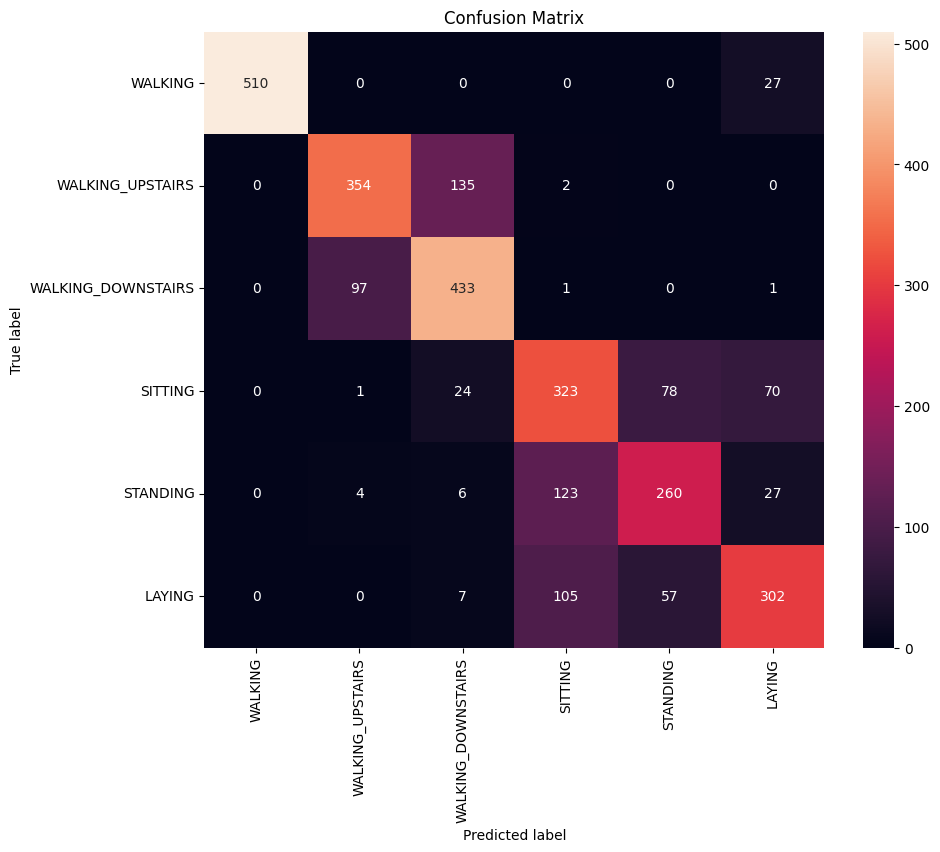

In [40]:
# Evaluate the model
model.eval()
with torch.no_grad():
    Y_pred = model(X_test)

    Y_pred = torch.softmax(Y_pred, dim=1)  
    Y_pred_classes = torch.argmax(Y_pred, axis=1)  
    Y_true_classes = torch.argmax(Y_test, axis=1) 
def confusion_matrix(Y_true, Y_pred):
    Y_true = pd.Series([ACTIVITIES[y.item()] for y in Y_true])
    Y_pred = pd.Series([ACTIVITIES[y.item()] for y in Y_pred])
    return pd.crosstab(Y_true, Y_pred, rownames=['True'], colnames=['Pred'])

result = confusion_matrix(Y_true_classes, Y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(result, annot=True, fmt="d", xticklabels=list(ACTIVITIES.values()), yticklabels=list(ACTIVITIES.values()))
plt.title("Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


### Using Only LSTM

In [4]:
class ActivityRecognitionModelLSTM(nn.Module):
    def __init__(self, input_dim, n_hidden, n_classes):
        super(ActivityRecognitionModelLSTM, self).__init__()
        
        # Reduce number of hidden units and remove bidirectional LSTM
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=n_hidden, batch_first=True, bidirectional=False)
        
        # Dropout Layer (before the output layer)
        self.dropout = nn.Dropout(0.3)  # Reduced dropout rate
        
        # Fully Connected Output Layer
        self.fc = nn.Linear(n_hidden, n_classes)  # Only n_hidden (no *2 for bidirectional)

    def forward(self, x):
        # Apply LSTM
        x, _ = self.lstm(x)  # Shape: (batch_size, seq_len, n_hidden)
        
        # Apply Dropout
        x = self.dropout(x)
        
        # Use the last output of the LSTM
        x = x[:, -1, :]  # Shape: (batch_size, n_hidden)
        
        # Output Layer
        x = self.fc(x)  # Shape: (batch_size, n_classes)
        return x


In [5]:
n_hidden =32
model = ActivityRecognitionModelLSTM(input_dim=input_dim, n_hidden=n_hidden, n_classes=n_classes)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.001)

# Training the model
epochs = 30
batch_size = 16

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(X_train)
    
    # Compute loss
    loss = criterion(outputs, Y_train)
    
    # Backward pass
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')
 

Epoch [5/30], Loss: 0.5889
Epoch [10/30], Loss: 0.4507
Epoch [15/30], Loss: 0.4323
Epoch [20/30], Loss: 0.4404
Epoch [25/30], Loss: 0.4096
Epoch [30/30], Loss: 0.4029


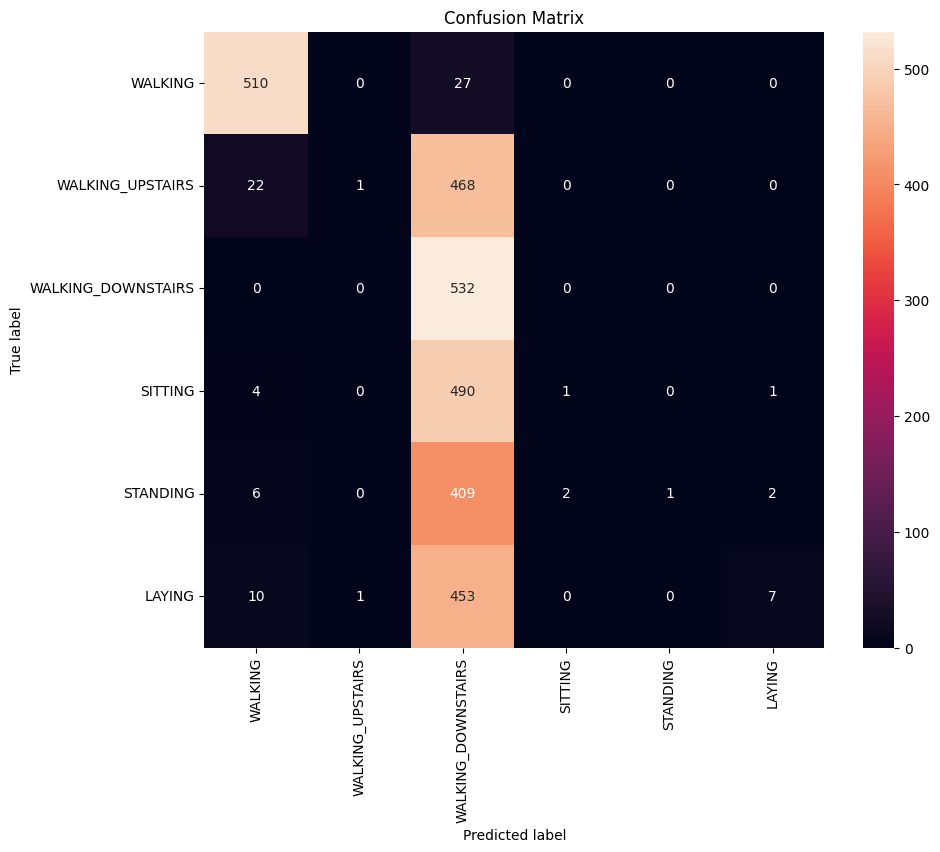

In [6]:
# Evaluate the model
model.eval()
with torch.no_grad():
    Y_pred = model(X_test)

    Y_pred = torch.softmax(Y_pred, dim=1)  
    Y_pred_classes = torch.argmax(Y_pred, axis=1)  
    Y_true_classes = torch.argmax(Y_test, axis=1) 
def confusion_matrix(Y_true, Y_pred):
    Y_true = pd.Series([ACTIVITIES[y.item()] for y in Y_true])
    Y_pred = pd.Series([ACTIVITIES[y.item()] for y in Y_pred])
    return pd.crosstab(Y_true, Y_pred, rownames=['True'], colnames=['Pred'])

result = confusion_matrix(Y_true_classes, Y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(result, annot=True, fmt="d", xticklabels=list(ACTIVITIES.values()), yticklabels=list(ACTIVITIES.values()))
plt.title("Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


### Using CNN and LSTM Combined

In [ ]:
class ActivityRecognitionModel(nn.Module):
    def __init__(self, input_dim, n_hidden, n_classes):
        super(ActivityRecognitionModel, self).__init__()
        
        # Convolutional Layers
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(output_size=32)  # Adaptive pooling for consistent output size
        
        # LSTM Layer
        self.lstm = nn.LSTM(input_size=128, hidden_size=n_hidden, batch_first=True, bidirectional=True)
        
        # Dropout Layer
        self.dropout = nn.Dropout(0.5)
        
        self.fc = nn.Linear(2 * n_hidden, n_classes)  
    def forward(self, x):
        # Apply Convolutional Layers
        x = x.permute(0, 2, 1)  # Change shape to (batch_size, input_dim, timesteps)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        
        # Apply LSTM
        x, _ = self.lstm(x.permute(0, 2, 1))  # Shape: (batch_size, seq_len, hidden_size*2)
        
        # Apply Dropout
        x = self.dropout(x)
        
        x = torch.mean(x, dim=1) 
        x = self.fc(x)  # Shape: (batch_size, n_classes)
        return x


In [25]:

n_hidden = 32
model = ActivityRecognitionModel(input_dim=input_dim, n_hidden=n_hidden, n_classes=n_classes)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.001)

# Training the model
epochs = 30
batch_size = 16

for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    
    # Forward pass
    outputs = model(X_train)
    
    # Compute loss
    loss = criterion(outputs, Y_train)
    
    # Backward pass
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')
 

Epoch [5/30], Loss: 0.4272
Epoch [10/30], Loss: 0.3552
Epoch [15/30], Loss: 0.3082
Epoch [20/30], Loss: 0.2684
Epoch [25/30], Loss: 0.2479
Epoch [30/30], Loss: 0.2351


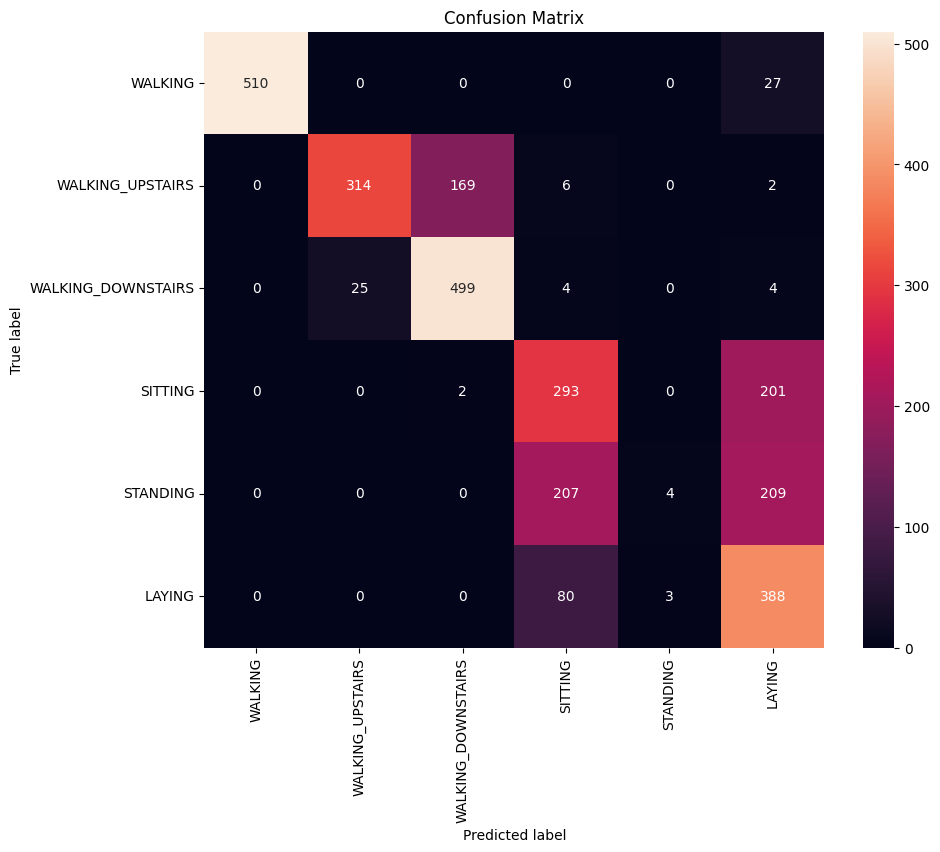

In [ ]:
# Evaluate the model
model.eval()
with torch.no_grad():
    Y_pred = model(X_test)

    Y_pred = torch.softmax(Y_pred, dim=1)  
    Y_pred_classes = torch.argmax(Y_pred, axis=1)  
    Y_true_classes = torch.argmax(Y_test, axis=1) 
def confusion_matrix(Y_true, Y_pred):
    Y_true = pd.Series([ACTIVITIES[y.item()] for y in Y_true])
    Y_pred = pd.Series([ACTIVITIES[y.item()] for y in Y_pred])
    return pd.crosstab(Y_true, Y_pred, rownames=['True'], colnames=['Pred'])

result = confusion_matrix(Y_true_classes, Y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(result, annot=True, fmt="d", xticklabels=list(ACTIVITIES.values()), yticklabels=list(ACTIVITIES.values()))
plt.title("Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()
